# 1D Burger's LaSDI-NM Example

In [13]:
import numpy as np
import numpy.linalg as LA

import matplotlib
import matplotlib.pyplot as plt
from itertools import product

import sys,time
import os
import pickle
import torch

sys.path.append("..") # Adds higher directory to python modules path.
import modLaSDIUtils as lasdiutils
import modAutoEncoder as autoencoder
from LaSDI import LaSDI

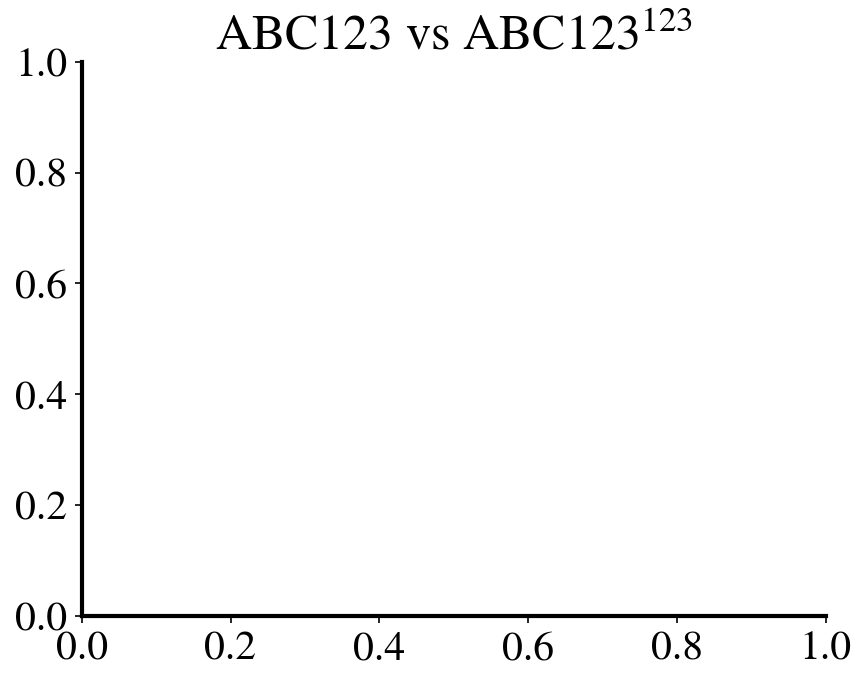

In [14]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.pyplot.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 10
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['axes.labelsize'] = 28
plt.rcParams['figure.dpi'] = 150

In [15]:
!nvidia-smi
torch.cuda.empty_cache()

3008.55s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Tue Mar  3 00:00:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.108                Driver Version: 581.83         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P8              3W /   60W |     608MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Load data and models produced from Build and Train files

In [16]:
# ### Load Data if Model Already Exists ###
snapshot_full = pickle.load(open("./data/snapshot_git.p", 'rb'))
snapshot_full = snapshot_full[:,:-1].astype('float32')
snapshot_full_FOM = pickle.load(open("./data/FOM.p",'rb'))
FOM_time = snapshot_full_FOM['time']
snapshot_full_FOM = snapshot_full_FOM['FOM'][:,:-1].astype('float32')


In [17]:
# Set print option
np.set_printoptions(threshold=sys.maxsize)

# Choose device that is not being used
gpu_ids = "0"
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]=gpu_ids

# Set device
device = autoencoder.getDevice()
print("Using device:", device, '\n')

Using device: cuda 



In [18]:
# set encoder and decoder types, activation function, etc.
encoder_class = autoencoder.Encoder
decoder_class = autoencoder.Decoder
f_activation = autoencoder.SiLU

maxk = 10
convergence_threshold = 1.0e-8

nx = 1001
dx = 6 / (nx - 1)
nt = 1000
tstop = 1
x=np.linspace(-3, 3, nx)

dt = tstop / nt 
c = dt/dx
t = np.linspace(0, tstop, nt)

m = 1000
f = 4
b = 36
db = 12
M2 = b + (m-1)*db
M1 = 2*m
mask = lasdiutils.create_mask_1d(m,b,db)

AE_fname = 'models/AE_git.tar'
encoder, decoder = autoencoder.readAEFromFile(  encoder_class,
                                                decoder_class,
                                                f_activation,
                                                mask,
                                                m, f, M1, M2,
                                                device,
                                                AE_fname )

Sparsity in 1000 by 12024 mask: 99.70%


### Generate latent-space trajectories from training data

In [19]:
amp_arr = np.array([.75,.85])
width_arr = np.array([.95,1.05])
P = list(product(amp_arr, width_arr))
P = np.array(P)
   
latent_space_SS = autoencoder.encodedSnapshots( encoder,
                                                snapshot_full,
                                                nt+1,
                                                device )

### Generate LaSDI-NM Model

(x0)' = -2.955 1 + -2.473 x0 + -1.353 x1 + -1.129 x2 + -2.240 x3
(x1)' =  1.286 1 + -2.390 x0 + -0.559 x1 + -0.840 x2 + -2.663 x3
(x2)' =  4.275 1 + -3.794 x0 + -0.642 x1 + -1.457 x2 + -4.626 x3
(x3)' =  1.203 1 +  4.376 x0 +  1.751 x1 +  1.896 x2 +  4.511 x3


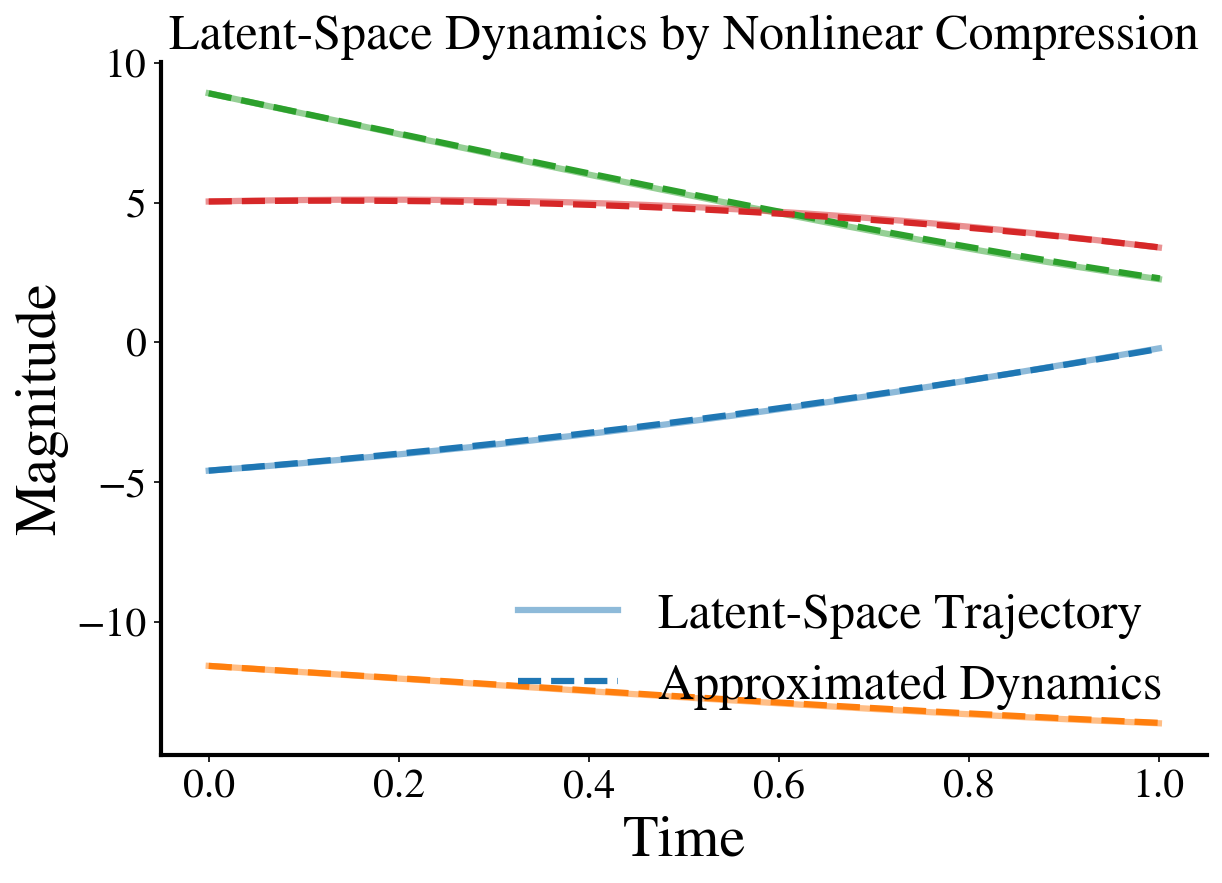

In [20]:
degree = 1
normal = 1
LaSDI_model = LaSDI(encoder, decoder, NN = True, device = device)
LaSDI_model.train_dynamics(latent_space_SS, P, dt)

### Generate ROM and visualize results

Final Position Error: 0.506%


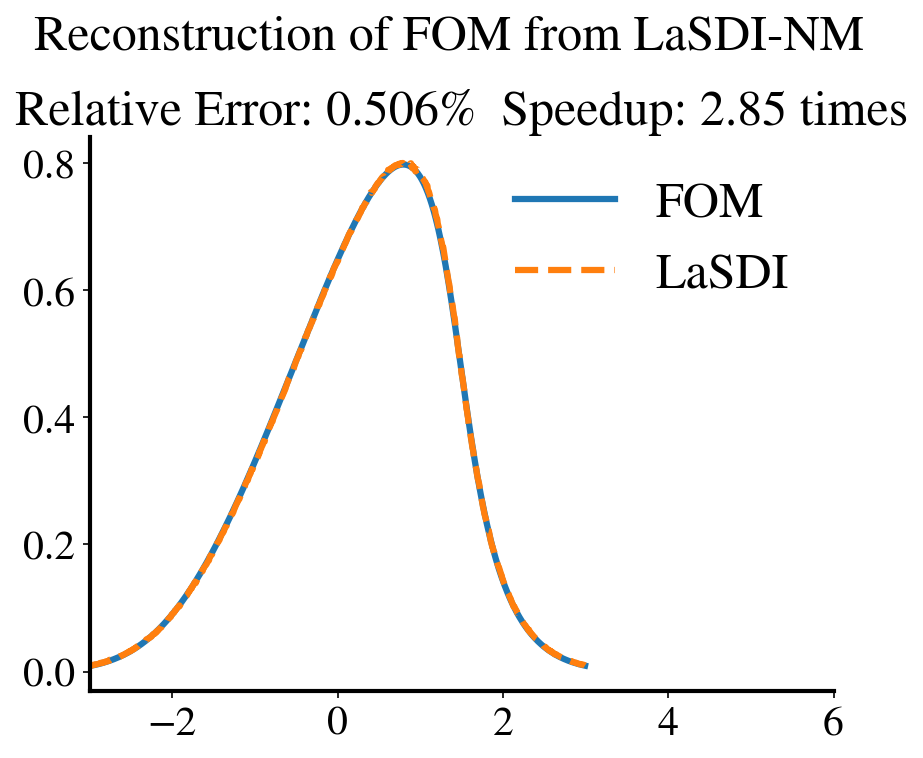

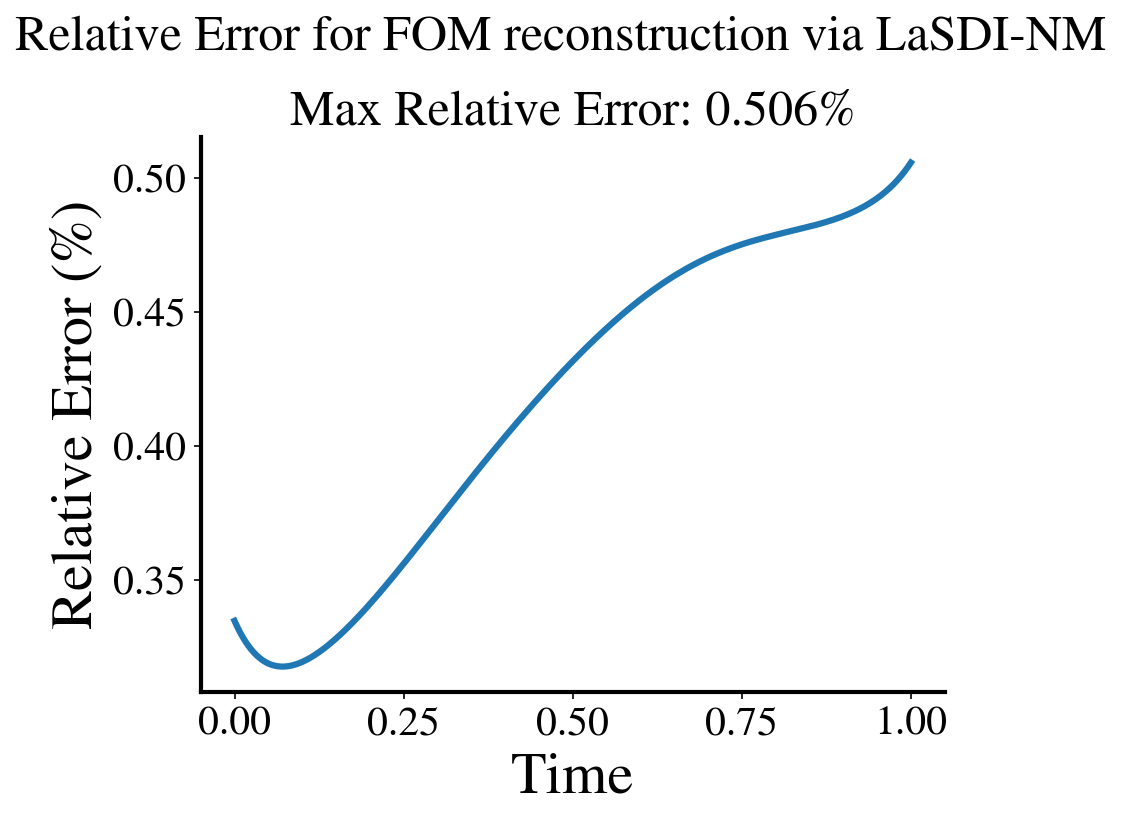

In [21]:
start = time.time()
FOM_recon = LaSDI_model.generate_ROM(snapshot_full_FOM[0], np.array([0.8,1.0]),t)
LaSDI_time = time.time()-start

print('Final Position Error: {:.3}%'.format(LA.norm(FOM_recon[-1]-snapshot_full_FOM[-2])/LA.norm(snapshot_full_FOM[-2])*100))
fig = plt.figure()
ax = plt.axes()
fig.suptitle('Reconstruction of FOM from LaSDI-NM', y = 1.05)
ax.set_title('Relative Error: {:.3}%  Speedup: {:.3} times'.format(LA.norm(FOM_recon[-1]-snapshot_full_FOM[-2])/LA.norm(snapshot_full_FOM[-2])*100, FOM_time/LaSDI_time))
ax.plot(x[:-1],snapshot_full_FOM[-1], label = 'FOM')
ax.plot(x[:-1], FOM_recon[-1],'--', label = 'LaSDI')
ax.legend()
ax.set_xlim(-3,6)


FOM_re = np.empty(nt)
for i in range(nt):
    FOM_re[i] = LA.norm(FOM_recon[i]-snapshot_full_FOM[i])/LA.norm(snapshot_full_FOM[i])

fig = plt.figure()
fig.suptitle('Relative Error for FOM reconstruction via LaSDI-NM', y = 1.05)
ax = plt.axes()
ax.set_title('Max Relative Error: {:.3}%'.format(np.amax(FOM_re)*100))
ax.plot(t, FOM_re*100)
ax.set_xlabel('Time')
ax.set_ylabel('Relative Error (%)')
torch.cuda.empty_cache()

[error-map] processed 50/441
[error-map] processed 100/441
[error-map] processed 150/441
[error-map] processed 200/441
[error-map] processed 250/441
[error-map] processed 300/441
[error-map] processed 350/441
[error-map] processed 400/441
[error-map] processed 441/441


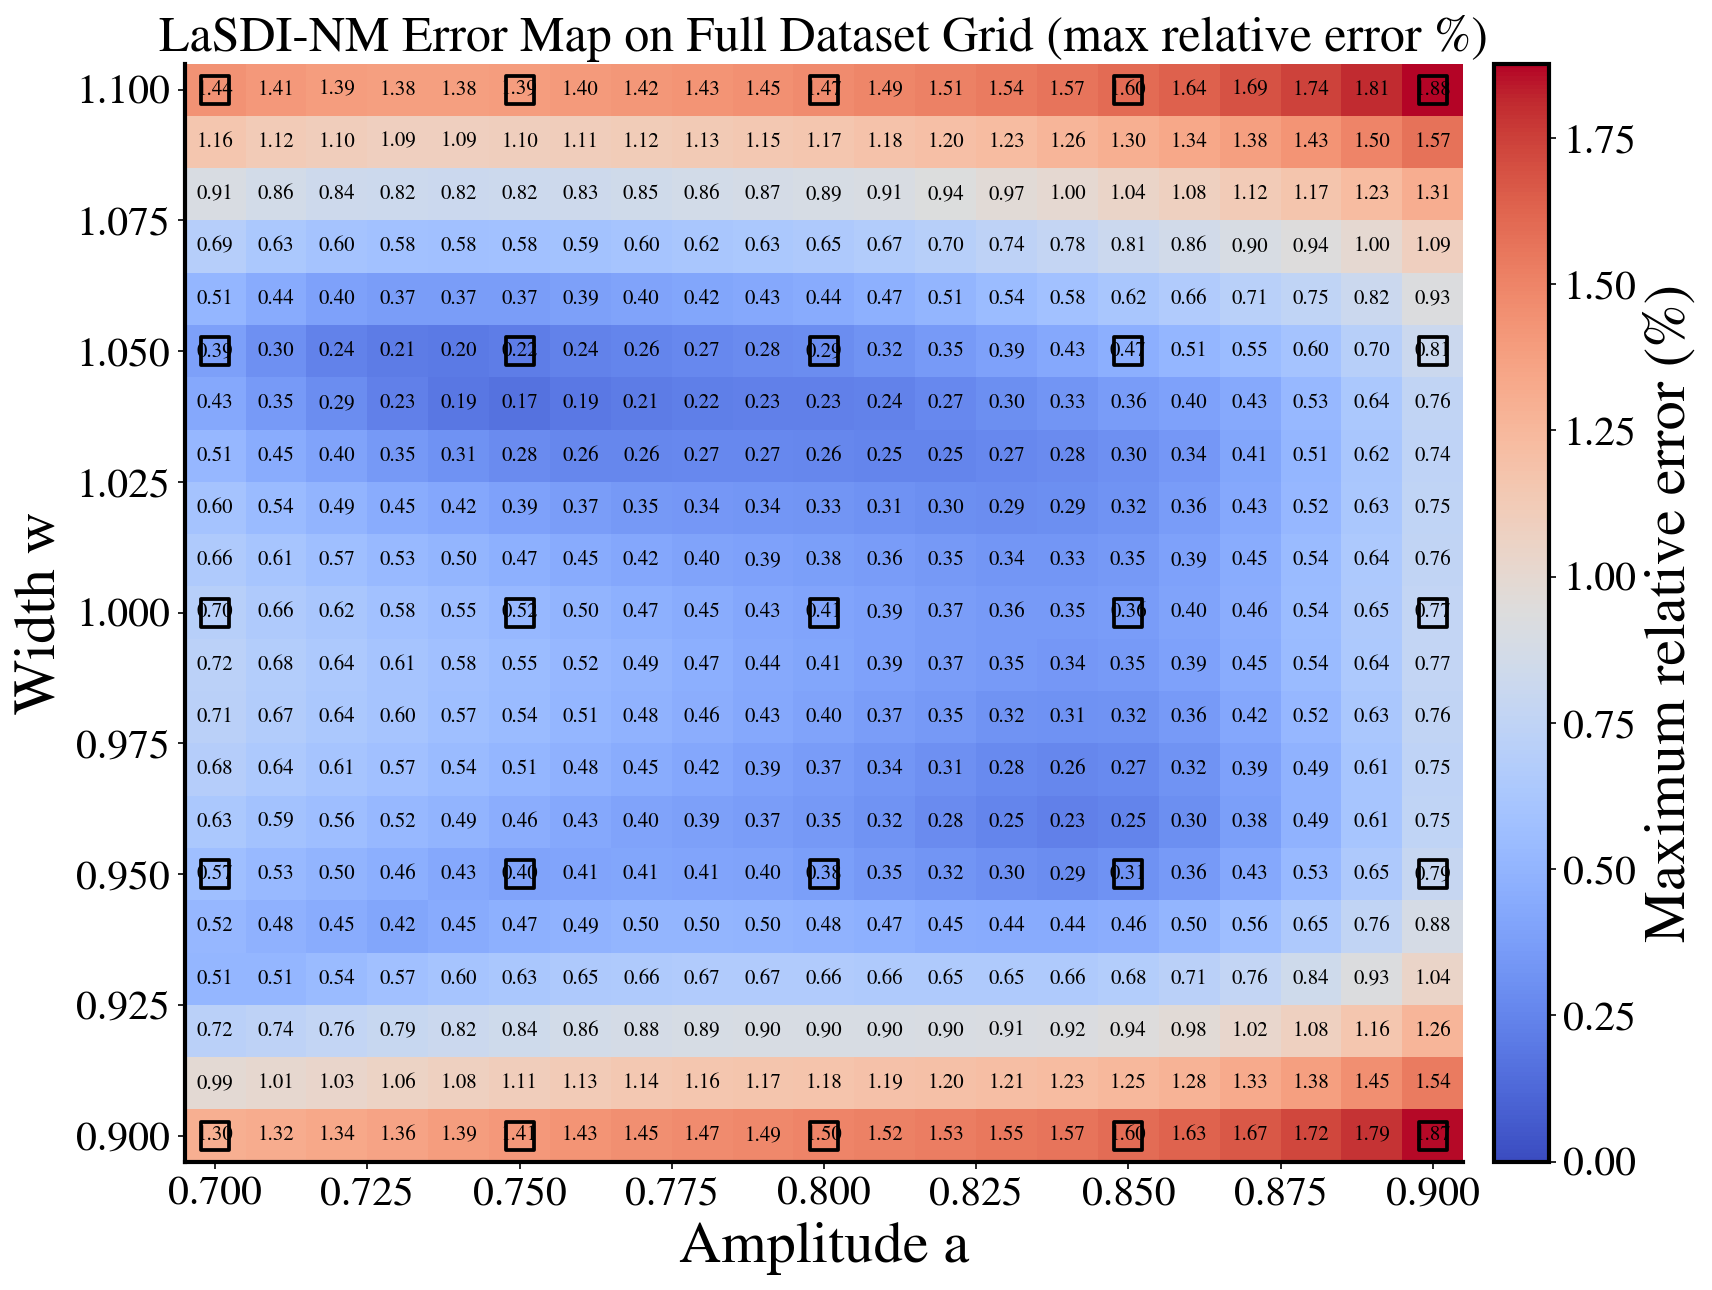

Saved error map image to: /home/uts22/projects/ML_phisycs/LaSDI/Burgers/results/lasdi_error_map_full_grid.png
Saved error map data  to: /home/uts22/projects/ML_phisycs/LaSDI/Burgers/results/lasdi_error_map_full_grid.npz


In [25]:
from pathlib import Path

# Error map on full dataset grid (e.g., 21x21 = 441 cases)
dataset_dir = Path('data/burgers')
index_path = dataset_dir / 'index.csv'
if not index_path.exists():
    raise FileNotFoundError(f'index.csv not found: {index_path.resolve()}')

rows = []
with index_path.open('r', encoding='utf-8') as handle:
    header = handle.readline()
    if 'filename' not in header:
        raise ValueError('index.csv header is invalid')
    for line in handle:
        filename, a_str, w_str = line.strip().split(',')
        rows.append((filename, float(a_str), float(w_str)))

if len(rows) == 0:
    raise RuntimeError('No parameter rows found in dataset index')

params_all = np.asarray([[a, w] for _, a, w in rows], dtype=float)
a_values = np.sort(np.unique(params_all[:, 0]))
w_values = np.sort(np.unique(params_all[:, 1]))
a_index = {float(a): j for j, a in enumerate(a_values)}
w_index = {float(w): i for i, w in enumerate(w_values)}
error_grid = np.full((w_values.size, a_values.size), np.nan, dtype=float)

for idx, (filename, a, w) in enumerate(rows, start=1):
    sample_path = dataset_dir / filename
    with np.load(sample_path) as data:
        if 'u' not in data:
            raise ValueError(f"'u' array missing in {sample_path}")
        u_seq = np.asarray(data['u'], dtype=float)

    # Accept both endpoint-included (1001) and endpoint-dropped (1000) snapshots.
    if u_seq.shape[1] == nx:
        u_seq = u_seq[:, :-1]
    elif u_seq.shape[1] != nx - 1:
        raise ValueError(f'Unexpected spatial size in {sample_path}: {u_seq.shape[1]}')

    u_true = u_seq[:len(t), :]
    u0 = u_true[0, :]
    u_pred = LaSDI_model.generate_ROM(u0, np.array([a, w]), t)

    n_t = min(u_true.shape[0], u_pred.shape[0])
    diff = u_true[:n_t] - u_pred[:n_t]
    denom = np.maximum(np.linalg.norm(u_true[:n_t], axis=1), 1.0e-12)
    rel = np.linalg.norm(diff, axis=1) / denom
    err_percent = 100.0 * np.max(rel)

    error_grid[w_index[float(w)], a_index[float(a)]] = err_percent

    if idx % 50 == 0 or idx == len(rows):
        print(f'[error-map] processed {idx}/{len(rows)}')


def _cell_edges(values):
    if values.size == 1:
        v = float(values[0])
        return np.array([v - 0.5, v + 0.5], dtype=float)
    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - 0.5 * (values[1] - values[0])
    right = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[left], mids, [right]])


def _select_training_params_5x5(a_vals, w_vals, samples_per_axis=5):
    if samples_per_axis <= 0:
        raise ValueError('samples_per_axis must be positive')
    if samples_per_axis > len(a_vals) or samples_per_axis > len(w_vals):
        raise ValueError('samples_per_axis exceeds available grid size')

    a_idx = np.round(np.linspace(0, len(a_vals) - 1, samples_per_axis)).astype(int)
    w_idx = np.round(np.linspace(0, len(w_vals) - 1, samples_per_axis)).astype(int)
    a_idx = np.asarray(list(dict.fromkeys(a_idx.tolist())), dtype=int)
    w_idx = np.asarray(list(dict.fromkeys(w_idx.tolist())), dtype=int)

    train_params = np.array([(float(a_vals[i]), float(w_vals[j])) for i in a_idx for j in w_idx], dtype=float)
    return train_params


a_edges = _cell_edges(a_values)
w_edges = _cell_edges(w_values)

fig, ax = plt.subplots(figsize=(12, 9))
mesh = ax.pcolormesh(
    a_edges,
    w_edges,
    error_grid,
    shading='auto',
    cmap='coolwarm',
    vmin=0.0,
    vmax=float(np.nanmax(error_grid) if np.any(~np.isnan(error_grid)) else 1.0),
)

# Write error magnitude on every grid cell.
for i, w in enumerate(w_values):
    for j, a in enumerate(a_values):
        value = error_grid[i, j]
        if np.isnan(value):
            continue
        ax.text(
            float(a),
            float(w),
            f'{value:.2f}',
            ha='center',
            va='center',
            fontsize=10,
            color='black',
        )

# Highlight the 25 training parameters used in Train.py (5x5) with square outlines.
train_params_25 = _select_training_params_5x5(a_values, w_values, samples_per_axis=5)
ax.scatter(
    train_params_25[:, 0],
    train_params_25[:, 1],
    marker='s',
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=1.8,
    #label='Training params (5x5=25)',
)
#ax.legend(loc='upper right')

ax.set_xlabel('Amplitude a')
ax.set_ylabel('Width w')
ax.set_title('LaSDI-NM Error Map on Full Dataset Grid (max relative error %)')
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label('Maximum relative error (%)')
fig.tight_layout()

out_dir = Path('results')
out_dir.mkdir(parents=True, exist_ok=True)
out_img = out_dir / 'lasdi_error_map_full_grid.png'
out_npz = out_dir / 'lasdi_error_map_full_grid.npz'
fig.savefig(out_img, dpi=300)
np.savez(
    out_npz,
    a_values=a_values,
    w_values=w_values,
    max_rel_err_percent=error_grid,
    train_params=train_params_25,
    eval_params=params_all,
)
plt.show()

print(f'Saved error map image to: {out_img.resolve()}')
print(f'Saved error map data  to: {out_npz.resolve()}')


